In [ ]:
import numpy as np
import scipy.sparse as sp
import json
import matplotlib.pyplot as plt
from PIL import Image

## Theoretical Understanding  and Basic Implementation of PageRank
Learning PageRank and the power method by analyzing the example graph in the textbook.

In [2]:
def load_graph(data_file_path):
    edges = []
    node_map = {}
    node_counter = 0
    with open(data_file_path, 'r') as f:
        for line in f:
            if not line.startswith('#'):
                parts = line.strip().split('\t')
                u, v = int(parts[0]), int(parts[1])
                if u not in node_map:
                    node_map[u] = node_counter
                    node_counter += 1
                if v not in node_map:
                    node_map[v] = node_counter
                    node_counter += 1
                edges.append((node_map[u], node_map[v]))
    edges = np.array(edges)
    n_nodes = node_counter
    return edges, n_nodes

edges, n_nodes = load_graph('../../data/Textbook-Example.txt')
print(f"Edges:\n{edges}\n")
print(f"Number of nodes:\n{n_nodes}")

Edges:
[[0 1]
 [1 2]
 [1 3]
 [2 3]
 [2 4]
 [2 5]
 [3 0]
 [4 5]
 [5 0]]

Number of nodes:
6


In [3]:
# A simple implementation of the matrix A according to the textbook.
# Use CSR format in the future for better performance.
def build_adjacency_matrix(edges, n_nodes, p):
    G = np.zeros((n_nodes, n_nodes))
    for i, j in edges:
        G[j, i] = 1
    out_degrees = G.sum(axis=0)
    D_diag = np.zeros(n_nodes)
    non_zero_mask = out_degrees > 0
    D_diag[non_zero_mask] = 1.0 / out_degrees[non_zero_mask]
    D = np.diag(D_diag)
    e = np.ones(n_nodes)
    f = np.full(n_nodes, 1.0 / n_nodes)
    f[non_zero_mask] = (1 - p) / n_nodes
    A = p * G @ D + np.outer(e, f)
    print(f"Matrix G:\n{G}\n")
    print(f"Matrix D:\n{D}\n")
    print(f"Vector e:\n{e}\n")
    print(f"Vector f:\n{f}\n")
    return A

A = build_adjacency_matrix(edges, n_nodes, 0.85)
print(f"Matrix A:\n{A}")

Matrix G:
[[0. 0. 0. 1. 0. 1.]
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0.]]

Matrix D:
[[1.         0.         0.         0.         0.         0.        ]
 [0.         0.5        0.         0.         0.         0.        ]
 [0.         0.         0.33333333 0.         0.         0.        ]
 [0.         0.         0.         1.         0.         0.        ]
 [0.         0.         0.         0.         1.         0.        ]
 [0.         0.         0.         0.         0.         1.        ]]

Vector e:
[1. 1. 1. 1. 1. 1.]

Vector f:
[0.025 0.025 0.025 0.025 0.025 0.025]

Matrix A:
[[0.025      0.025      0.025      0.875      0.025      0.875     ]
 [0.875      0.025      0.025      0.025      0.025      0.025     ]
 [0.025      0.45       0.025      0.025      0.025      0.025     ]
 [0.025      0.45       0.30833333 0.025      0.025      0.025     ]
 [0.025      0.025      0.30833333 0.025      0.025      0.025     ]
 

In [4]:
def build_components(edges, n_nodes, p):
    cols = edges[:, 0]
    rows = edges[:, 1]
    data = np.ones(len(edges))
    G = sp.csr_matrix((data, (rows, cols)), shape=(n_nodes, n_nodes))
    out_degrees = np.array(G.sum(axis=0)).flatten()
    D = np.zeros(n_nodes)
    non_zero_mask = out_degrees > 0
    D[non_zero_mask] = 1.0 / out_degrees[non_zero_mask]
    e = np.ones(n_nodes)
    f = np.zeros(n_nodes)
    for i in range(n_nodes):
        if out_degrees[i] != 0:
            f[i] = (1-p)/n_nodes
        else:
            f[i] = 1/n_nodes
    v = e * 1/n_nodes
    return G, D, e, f, v

G, D, e, f, v = build_components(edges, n_nodes, 0.85)
print(f"Matrix G:\n{G.toarray()}\n")
print(f"Vector D:\n{D}\n")
print(f"Vector e:\n{e}\n")
print(f"Vector f:\n{f}\n")
print(f"Vector v:\n{v}\n")

Matrix G:
[[0. 0. 0. 1. 0. 1.]
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0.]]

Vector D:
[1.         0.5        0.33333333 1.         1.         1.        ]

Vector e:
[1. 1. 1. 1. 1. 1.]

Vector f:
[0.025 0.025 0.025 0.025 0.025 0.025]

Vector v:
[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]



In [5]:
def power_method_A(A, n_nodes, max_iter=100, tol=1e-6):
    x = np.random.rand(n_nodes)
    x /= np.linalg.norm(x, 1)
    for _ in range(max_iter):
        x_new = A @ x
        x_new /= np.linalg.norm(x_new, 1)
        if np.linalg.norm(x_new - x, 1) < tol:
            break
        x = x_new
    return x

pagerank = power_method_A(A, n_nodes)
print(f"PageRank:\n{pagerank}")

PageRank:
[0.26752827 0.252399   0.13226933 0.16974567 0.06247635 0.11558138]


In [6]:
def power_method_components(G, D, e, f, n_nodes, p, max_iter=100, tol=1e-6):
    x = np.random.rand(n_nodes)
    x /= np.linalg.norm(x, 1)
    for _ in range(max_iter):
        x_new = p * G @ (D * x) + e * (f @ x)
        x_new /= np.linalg.norm(x_new, 1)
        if np.linalg.norm(x_new - x, 1) < tol:
            break
        x = x_new
    return x

pagerank = power_method_components(G, D, e, f, n_nodes, 0.85)
print(f"PageRank:\n{pagerank}")

PageRank:
[0.26752795 0.25239868 0.13226968 0.16974608 0.06247641 0.11558121]


In [8]:
def power_method_standard(G, D, e, v, n_nodes, p, max_iter=100, tol=1e-6):
    x = np.random.rand(n_nodes)
    x /= np.linalg.norm(x, 1)
    for _ in range(max_iter):
        x_new = p * G @ (D * x) + (1-p) * e * (v @ x)
        x_new /= np.linalg.norm(x_new, 1)
        if np.linalg.norm(x_new - x, 1) < tol:
            break
        x = x_new
    return x

pagerank = power_method_standard(G, D, e, v, n_nodes, 0.85)
print(f"PageRank:\n{pagerank}")

PageRank:
[0.26752824 0.25239887 0.13226938 0.16974576 0.06247638 0.11558137]


## Plot Experiments Results

Experiment results:
[{'perturbation_percent': '0.01%', 'perturbation_ratio': 1e-05, 'cold_start': {'iterations': 26, 'execution_time_sec': 0.003962}, 'warm_start': {'iterations': 16, 'execution_time_sec': 0.002227, 'speedup': 1.78}, 'local_push': {'iterations': 15, 'execution_time_sec': 0.002321, 'speedup': 1.71}}, {'perturbation_percent': '0.05%', 'perturbation_ratio': 5e-05, 'cold_start': {'iterations': 26, 'execution_time_sec': 0.003777}, 'warm_start': {'iterations': 17, 'execution_time_sec': 0.002308, 'speedup': 1.64}, 'local_push': {'iterations': 16, 'execution_time_sec': 0.002077, 'speedup': 1.82}}, {'perturbation_percent': '0.1%', 'perturbation_ratio': 0.0001, 'cold_start': {'iterations': 26, 'execution_time_sec': 0.003547}, 'warm_start': {'iterations': 18, 'execution_time_sec': 0.002417, 'speedup': 1.47}, 'local_push': {'iterations': 17, 'execution_time_sec': 0.002288, 'speedup': 1.55}}, {'perturbation_percent': '0.5%', 'perturbation_ratio': 0.0005, 'cold_start': {'iterations':

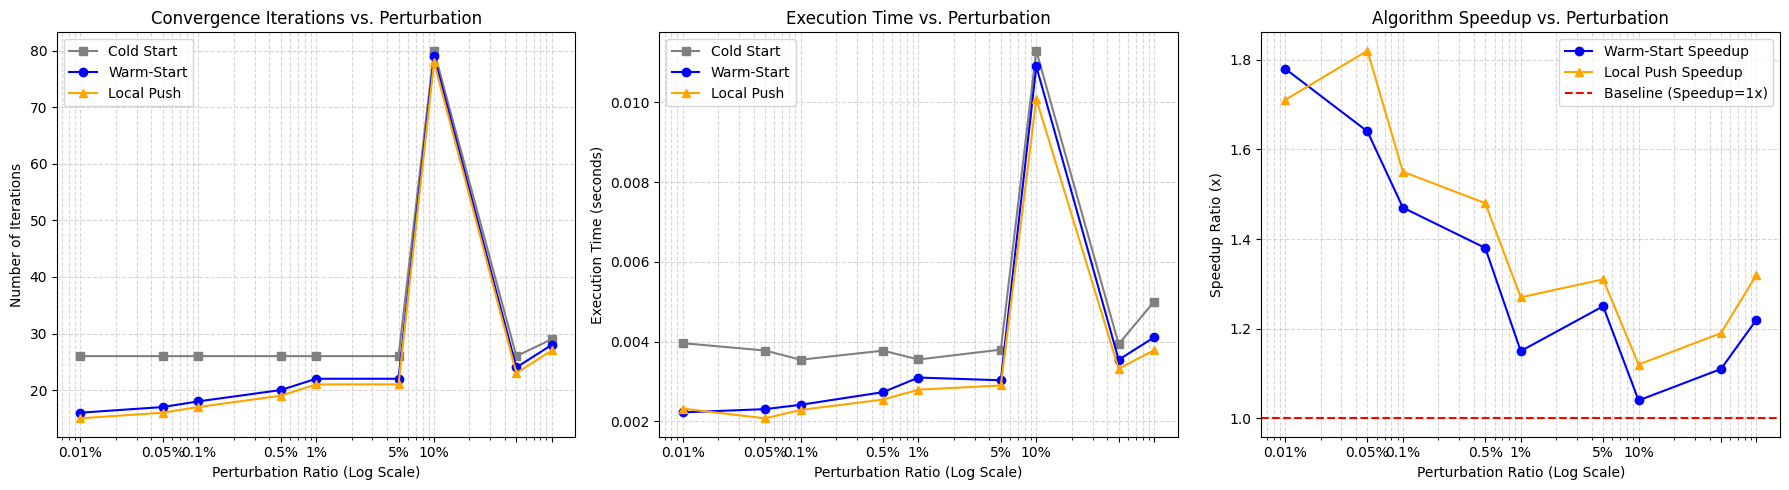

In [ ]:
with open('../../results/performance_experiment_results.json', 'r') as f:
    data = json.load(f)
print(f"Experiment results:\n{data}")

ratios = [item['perturbation_ratio'] for item in data]
labels = [item['perturbation_percent'] for item in data]

cold_iters = [item['cold_start']['iterations'] for item in data]
warm_iters =[item['warm_start']['iterations'] for item in data]
local_iters = [item['local_push']['iterations'] for item in data]

cold_times = [item['cold_start']['execution_time_sec'] for item in data]
warm_times = [item['warm_start']['execution_time_sec'] for item in data]
local_times = [item['local_push']['execution_time_sec'] for item in data]

warm_speedups = [item['warm_start']['speedup'] for item in data]
local_speedups = [item['local_push']['speedup'] for item in data]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------------------------------------
# 图 1：收敛迭代次数对比 (Iterations)
# ---------------------------------------------------------
axes[0].plot(ratios, cold_iters, marker='s', linestyle='-', color='gray', label='Cold Start')
axes[0].plot(ratios, warm_iters, marker='o', linestyle='-', color='blue', label='Warm-Start')
axes[0].plot(ratios, local_iters, marker='^', linestyle='-', color='orange', label='Local Push')
axes[0].set_xscale('log')
axes[0].set_xticks(ratios)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel('Perturbation Ratio (Log Scale)')
axes[0].set_ylabel('Number of Iterations')
axes[0].set_title('Convergence Iterations vs. Perturbation')
axes[0].legend()
axes[0].grid(True, which="both", ls="--", alpha=0.5)

# ---------------------------------------------------------
# 图 2：运行时间对比 (Execution Time)
# ---------------------------------------------------------
axes[1].plot(ratios, cold_times, marker='s', linestyle='-', color='gray', label='Cold Start')
axes[1].plot(ratios, warm_times, marker='o', linestyle='-', color='blue', label='Warm-Start')
axes[1].plot(ratios, local_times, marker='^', linestyle='-', color='orange', label='Local Push')
axes[1].set_xscale('log')
axes[1].set_xticks(ratios)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel('Perturbation Ratio (Log Scale)')
axes[1].set_ylabel('Execution Time (seconds)')
axes[1].set_title('Execution Time vs. Perturbation')
axes[1].legend()
axes[1].grid(True, which="both", ls="--", alpha=0.5)

# ---------------------------------------------------------
# 图 3：相对冷启动的加速比 (Speedup Ratio)
# ---------------------------------------------------------
axes[2].plot(ratios, warm_speedups, marker='o', linestyle='-', color='blue', label='Warm-Start Speedup')
axes[2].plot(ratios, local_speedups, marker='^', linestyle='-', color='orange', label='Local Push Speedup')

# 画一条 y=1 的红色虚线，作为盈亏平衡线
axes[2].axhline(y=1.0, color='red', linestyle='--', label='Baseline (Speedup=1x)')

axes[2].set_xscale('log')
axes[2].set_xticks(ratios)
axes[2].set_xticklabels(labels)
axes[2].set_xlabel('Perturbation Ratio (Log Scale)')
axes[2].set_ylabel('Speedup Ratio (x)')
axes[2].set_title('Algorithm Speedup vs. Perturbation')
axes[2].legend()
axes[2].grid(True, which="both", ls="--", alpha=0.5)

# 3. 调整布局并保存
plt.tight_layout()
plt.savefig("../../results/performance_and_scalability.png", dpi=300)
print(f"[*] 可视化图表已成功生成并保存为: '../../results/performance_and_scalability.png'")

In [ ]:
def merge_images_horizontal(image1_path, image2_path, output_path):
    img1 = Image.open(image1_path)
    img2 = Image.open(image2_path)
    w1, h1 = img1.size
    w2, h2 = img2.size
    new_width = w1 + w2
    new_height = max(h1, h2)
    new_img = Image.new('RGBA', (new_width, new_height), (0, 0, 0, 0))
    new_img.paste(img1, (0, 0))
    new_img.paste(img2, (w1, 0))
    new_img.save(output_path)
    print(f"[*] 成功合并！保存至: {output_path}")

merge_images_horizontal('../../results/matrix_perturbation_drop_ratio_results.png', '../../results/matrix_perturbation_add_ratio_results.png', '../../results/matrix_perturbation_merged.png')

成功合并！保存至: ../../results/matrix_perturbation_merged.png


[*] 可视化图表已保存至: '../../results/sensitivity.png'


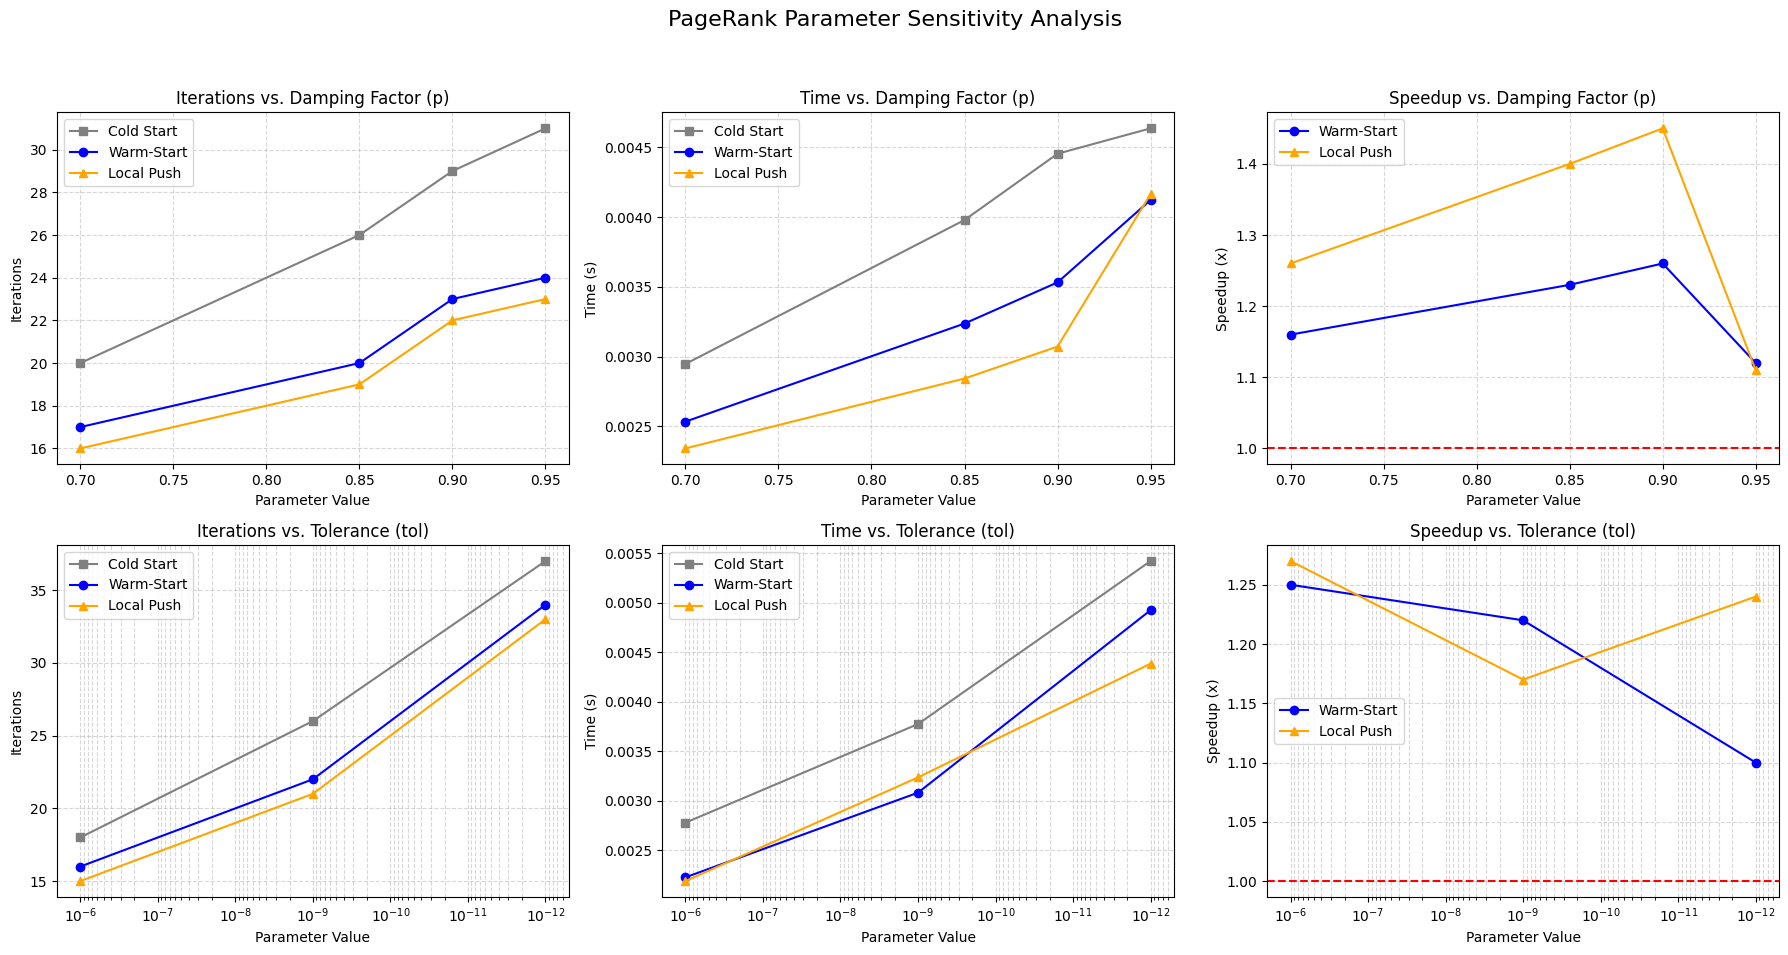

In [ ]:
with open('../../results/sensitivity_experiment_results.json', 'r', encoding='utf-8') as f:
        data = json.load(f)

p_data = data['p_sensitivity']
t_data = data['tol_sensitivity']

# 创建 2x3 的画布
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('PageRank Parameter Sensitivity Analysis', fontsize=16)

# 颜色配置
colors = {'cold': 'gray', 'warm': 'blue', 'local': 'orange'}
markers = {'cold': 's', 'warm': 'o', 'local': '^'}

# =========================================================
# 第一行：p Sensitivity (阻尼系数)
# =========================================================
ps = [item['p'] for item in p_data]

# 1.1 Iterations
axes[0, 0].plot(ps, [item['cold_start']['iterations'] for item in p_data], marker=markers['cold'], color=colors['cold'], label='Cold Start')
axes[0, 0].plot(ps, [item['warm_start']['iterations'] for item in p_data], marker=markers['warm'], color=colors['warm'], label='Warm-Start')
axes[0, 0].plot(ps, [item['local_push']['iterations'] for item in p_data], marker=markers['local'], color=colors['local'], label='Local Push')
axes[0, 0].set_title('Iterations vs. Damping Factor (p)')
axes[0, 0].set_ylabel('Iterations')

# 1.2 Execution Time
axes[0, 1].plot(ps, [item['cold_start']['execution_time_sec'] for item in p_data], marker=markers['cold'], color=colors['cold'], label='Cold Start')
axes[0, 1].plot(ps, [item['warm_start']['execution_time_sec'] for item in p_data], marker=markers['warm'], color=colors['warm'], label='Warm-Start')
axes[0, 1].plot(ps, [item['local_push']['execution_time_sec'] for item in p_data], marker=markers['local'], color=colors['local'], label='Local Push')
axes[0, 1].set_title('Time vs. Damping Factor (p)')
axes[0, 1].set_ylabel('Time (s)')

# 1.3 Speedup
axes[0, 2].plot(ps, [item['warm_start']['speedup'] for item in p_data], marker=markers['warm'], color=colors['warm'], label='Warm-Start')
axes[0, 2].plot(ps, [item['local_push']['speedup'] for item in p_data], marker=markers['local'], color=colors['local'], label='Local Push')
axes[0, 2].axhline(y=1.0, color='red', linestyle='--')
axes[0, 2].set_title('Speedup vs. Damping Factor (p)')
axes[0, 2].set_ylabel('Speedup (x)')

# =========================================================
# 第二行：tol Sensitivity (容忍度)
# =========================================================
tols = [float(item['tol_str']) for item in t_data]
tol_labels = [item['tol_str'] for item in t_data]

# 2.1 Iterations
axes[1, 0].plot(tols, [item['cold_start']['iterations'] for item in t_data], marker=markers['cold'], color=colors['cold'], label='Cold Start')
axes[1, 0].plot(tols, [item['warm_start']['iterations'] for item in t_data], marker=markers['warm'], color=colors['warm'], label='Warm-Start')
axes[1, 0].plot(tols, [item['local_push']['iterations'] for item in t_data], marker=markers['local'], color=colors['local'], label='Local Push')
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Iterations vs. Tolerance (tol)')
axes[1, 0].set_ylabel('Iterations')
axes[1, 0].invert_xaxis()

# 2.2 Execution Time
axes[1, 1].plot(tols, [item['cold_start']['execution_time_sec'] for item in t_data], marker=markers['cold'], color=colors['cold'], label='Cold Start')
axes[1, 1].plot(tols, [item['warm_start']['execution_time_sec'] for item in t_data], marker=markers['warm'], color=colors['warm'], label='Warm-Start')
axes[1, 1].plot(tols, [item['local_push']['execution_time_sec'] for item in t_data], marker=markers['local'], color=colors['local'], label='Local Push')
axes[1, 1].set_xscale('log')
axes[1, 1].set_title('Time vs. Tolerance (tol)')
axes[1, 1].set_ylabel('Time (s)')
axes[1, 1].invert_xaxis()

# 2.3 Speedup
axes[1, 2].plot(tols, [item['warm_start']['speedup'] for item in t_data], marker=markers['warm'], color=colors['warm'], label='Warm-Start')
axes[1, 2].plot(tols, [item['local_push']['speedup'] for item in t_data], marker=markers['local'], color=colors['local'], label='Local Push')
axes[1, 2].axhline(y=1.0, color='red', linestyle='--')
axes[1, 2].set_xscale('log')
axes[1, 2].set_title('Speedup vs. Tolerance (tol)')
axes[1, 2].set_ylabel('Speedup (x)')
axes[1, 2].invert_xaxis()

for ax_row in axes:
    for ax in ax_row:
        ax.legend()
        ax.grid(True, which="both", ls="--", alpha=0.5)
        ax.set_xlabel('Parameter Value')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('../../results/sensitivity.png', dpi=300)
print(f"[*] 可视化图表已保存至: '../../results/sensitivity.png'")